In [2]:
# This allows access to dataset stored in Google Drive

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Dataset must be structured as:
# dataset/train, dataset/valid, dataset/test

train_folder = '/content/drive/MyDrive/dataset/train'
valid_folder = '/content/drive/MyDrive/dataset/valid'
test_folder  = '/content/drive/MyDrive/dataset/test'

In [4]:
# IMPORT LIBRARIES


import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.metrics import classification_report, confusion_matrix

In [5]:
#  4. IMAGE PREPROCESSING
# All images resized and normalized

IMAGE_SIZE = (224, 224)
BATCH_SIZE = 16

# Data augmentation to improve generalization
train_datagen = ImageDataGenerator(
    rescale=1./255,             # Normalization (0–255 → 0–1)
    horizontal_flip=True,       # Flip images
    rotation_range=20,          # Rotate images
    zoom_range=0.2              # Zoom images
)

# Validation data only normalized
valid_datagen = ImageDataGenerator(rescale=1./255)

In [7]:
#  5 LOAD DATASET

train_generator = train_datagen.flow_from_directory(
    train_folder,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

valid_generator = valid_datagen.flow_from_directory(
    valid_folder,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

print("Class Labels:", train_generator.class_indices)

Found 519 images belonging to 4 classes.
Found 72 images belonging to 4 classes.
Class Labels: {'adenocarcinoma': 0, 'large_cell': 1, 'normal': 2, 'squamous': 3}


In [6]:
# MODEL (TRANSFER LEARNING - XCEPTION)
# Using pretrained CNN model

base_model = tf.keras.applications.Xception(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze most layers to avoid overfitting
for layer in base_model.layers[:-30]:
    layer.trainable = False

83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 7s 0us/step


In [7]:
# BUILD FINAL MODEL
model = Sequential([
    base_model,                      # Feature extractor
    GlobalAveragePooling2D(),        # Reduce dimensions
    Dropout(0.5),                    # Prevent overfitting
    Dense(4, activation='softmax')   # 4 output classes
])


In [8]:
# COMPILE MODEL

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ xception (Functional)           │ (None, 7, 7, 2048)     │    20,861,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │         8,196 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,869,676 (79.61 MB)

 Trainable params: 8,948,548 (34.14 MB)

 Non-trainable params: 11,921,128 (45.48 MB)

In [9]:
# CALLBACKS (OPTIMIZATION)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

lr_reduce = ReduceLROnPlateau(
    monitor='val_loss',
    patience=3,
    factor=0.3
)

In [10]:
# TRAIN MODEL

history = model.fit(
    train_generator,
    validation_data=valid_generator,
    epochs=20,
    callbacks=[early_stop, lr_reduce]
)


Epoch 1/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 335s 9s/step - accuracy: 0.4297 - loss: 1.2369 - val_accuracy: 0.5000 - val_loss: 1.2060 - learning_rate: 1.0000e-04
Epoch 2/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 11s 346ms/step - accuracy: 0.6532 - loss: 0.8988 - val_accuracy: 0.5556 - val_loss: 1.2682 - learning_rate: 1.0000e-04
Epoch 3/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 12s 361ms/step - accuracy: 0.7457 - loss: 0.6686 - val_accuracy: 0.5556 - val_loss: 1.4219 - learning_rate: 1.0000e-04
Epoch 4/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 12s 353ms/step - accuracy: 0.8420 - loss: 0.4718 - val_accuracy: 0.5833 - val_loss: 1.2880 - learning_rate: 1.0000e-04
Epoch 5/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 11s 321ms/step - accuracy: 0.8748 - loss: 0.3953 - val_accuracy: 0.6528 - val_loss: 0.9151 - learning_rate: 3.0000e-05
Epoch 6/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 11s 329ms/step - accuracy: 0.8921 - loss: 0.3384 - val_accuracy: 0.7361 - val_loss: 0.6337 - learning_rate: 3.0000e-05
Epoch 7/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 12s 357ms/step - accur

In [11]:
# 11. FINAL ACCURACY
print("Training Accuracy:", history.history['accuracy'][-1])
print("Validation Accuracy:", history.history['val_accuracy'][-1])


Training Accuracy: 0.9653179049491882
Validation Accuracy: 0.8611111044883728


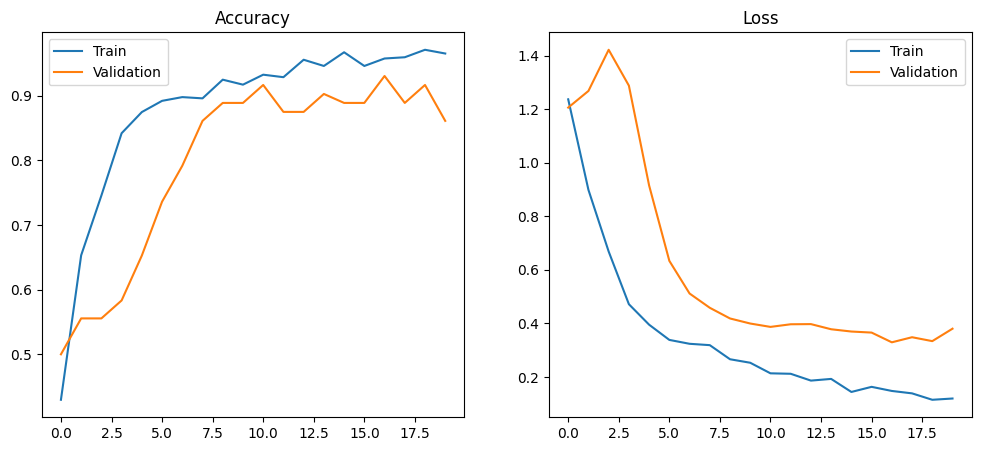

In [16]:
# PLOT RESULTS

plt.figure(figsize=(12,5))

# Accuracy graph
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Accuracy')
plt.legend(['Train', 'Validation'])

# Loss graph
plt.subplot(1,2,2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Loss')
plt.legend(['Train', 'Validation'])

plt.show()

In [17]:
# 13. SAVE MODEL


model.save('/content/drive/MyDrive/lung_cancer_model_final2.h5')

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 242ms/step


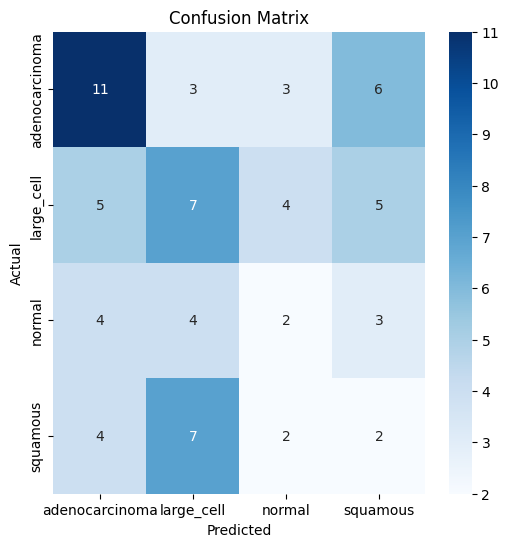


📊 Classification Report:
                precision    recall  f1-score   support

adenocarcinoma       0.46      0.48      0.47        23
    large_cell       0.33      0.33      0.33        21
        normal       0.18      0.15      0.17        13
      squamous       0.12      0.13      0.13        15

      accuracy                           0.31        72
     macro avg       0.27      0.27      0.27        72
  weighted avg       0.30      0.31      0.30        72



In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# Predictions
Y_pred = model.predict(valid_generator)
y_pred = np.argmax(Y_pred, axis=1)

# True labels
y_true = valid_generator.classes

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

# Class labels
class_names = list(valid_generator.class_indices.keys())

# Plot
plt.figure(figsize=(6,6))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Classification Report
print("\n Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

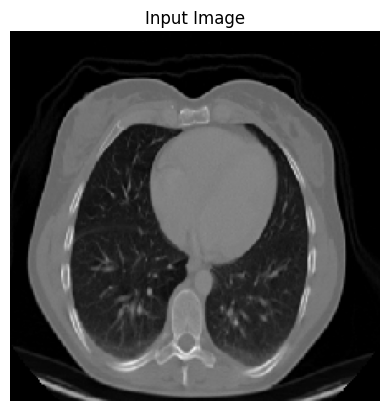

1/1 ━━━━━━━━━━━━━━━━━━━━ 13s 13s/step
Predicted Class: adenocarcinoma


In [22]:
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
import numpy as np

def predict_image(img_path):
    # Load image
    img = image.load_img(img_path, target_size=IMAGE_SIZE)

    # Display image
    plt.imshow(img)
    plt.title("Input Image")
    plt.axis('off')
    plt.show()

    # Preprocess
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    # Predict
    prediction = model.predict(img_array)
    class_idx = np.argmax(prediction)

    labels = list(train_generator.class_indices.keys())

    return labels[class_idx]


#  Test Image
img_path = '/content/000108 (3).png'  # your image path
result = predict_image(img_path)

print("Predicted Class:", result)

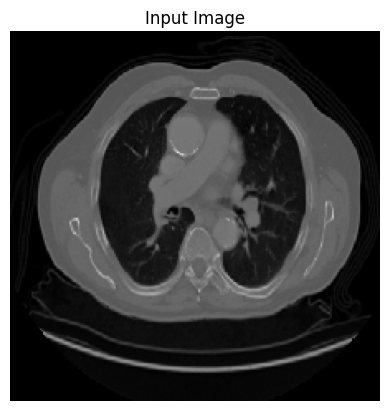

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
Predicted Class: squamous


In [23]:
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
import numpy as np

def predict_image(img_path):
    # Load image
    img = image.load_img(img_path, target_size=IMAGE_SIZE)

    # Display image
    plt.imshow(img)
    plt.title("Input Image")
    plt.axis('off')
    plt.show()

    # Preprocess
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    # Predict
    prediction = model.predict(img_array)
    class_idx = np.argmax(prediction)

    labels = list(train_generator.class_indices.keys())

    return labels[class_idx]


#  Test Image
img_path = '/content/000127.png'  # your image path
result = predict_image(img_path)

print("Predicted Class:", result)

In [24]:
#create test generator
test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    test_folder,
    target_size=IMAGE_SIZE,
    batch_size=16,
    class_mode='categorical',
    shuffle=False   # VERY IMPORTANT
)

Found 315 images belonging to 4 classes.


In [25]:
#test accuracy
loss, accuracy = model.evaluate(test_generator)

print("Test Accuracy:", accuracy)

20/20 ━━━━━━━━━━━━━━━━━━━━ 158s 8s/step - accuracy: 0.8286 - loss: 0.4631
Test Accuracy: 0.8285714387893677


In [26]:
#prediction on test dataset
Y_pred = model.predict(test_generator)
y_pred = np.argmax(Y_pred, axis=1)

20/20 ━━━━━━━━━━━━━━━━━━━━ 11s 565ms/step


In [27]:
#classification report combined
# Evaluate on test data
loss, accuracy = model.evaluate(test_generator)
print(f"\nTest Accuracy: {accuracy:.4f}")

# Predictions
import numpy as np
from sklearn.metrics import classification_report

Y_pred = model.predict(test_generator)
y_pred = np.argmax(Y_pred, axis=1)

# Classification Report
print("\nClassification Report:\n")
print(classification_report(
    test_generator.classes,
    y_pred,
    target_names=list(test_generator.class_indices.keys())
))

20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 128ms/step - accuracy: 0.8286 - loss: 0.4631

Test Accuracy: 0.8286
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 154ms/step

Classification Report:

                precision    recall  f1-score   support

adenocarcinoma       0.89      0.73      0.80       120
    large_cell       0.61      0.98      0.75        51
        normal       1.00      1.00      1.00        54
      squamous       0.86      0.77      0.81        90

      accuracy                           0.83       315
     macro avg       0.84      0.87      0.84       315
  weighted avg       0.86      0.83      0.83       315



In [28]:
# 🔹 Train Accuracy (from training history)
train_acc = history.history['accuracy'][-1]
val_acc = history.history['val_accuracy'][-1]

print(f"Train Accuracy: {train_acc:.4f}")
print(f"Validation Accuracy: {val_acc:.4f}")

# 🔹 Test Accuracy (final evaluation)
test_loss, test_acc = model.evaluate(test_generator)

print(f"Test Accuracy: {test_acc:.4f}")

Train Accuracy: 0.9653
Validation Accuracy: 0.8611
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 134ms/step - accuracy: 0.8286 - loss: 0.4631
Test Accuracy: 0.8286
